In [1]:
from dataclasses import dataclass, field
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Monte Carlo Simulation for Agile Estimation
In the previous notebook `01_problem_definition` it got established that point estimates systematicaly fail when applied to work with inherent variance. Using real integration data from my team's Jira history, the analysis showed that the standard 14-day commitment succeeds only 5.1% of the time against historical data. The actual distribution of completion times spans a wide range and places the point estimate entirely outside the standard deviation band. 

The data cleaning exercise added a further clarity: even the underlying dataset required scrutiny! Misclassified tickets were silently pulling the mean down by 7 days, making the original 20% apparent success rate an artefact of poor data hygiene rather than real performance. Once corrected, the picture became very different: more integrations exceed 60 days (10.3%) than meet the 14-day promise (5.1%)!

The conclusion that followe was not that estimation is impossible but rather that a single point estimate is the wrong tool when dealing with high variance. What is needed is a forecasting approach that reflects uncertainty honestly, uses empirical data rather than assumptions, and produces outputs that stakeholders can act on.

This notebook puts that approach to the test. Monte Carlo simulation is selected because it shifts from deterministic promises to probabilistic forecasts. It samples directly from observed history, outputs probability distributions rather than false certainty, and scales naturally to multiple work items addressing the compounding uncertainty that point estimates ignore entirely as the team rarely works on 1 integration at a time.

The question this notebook explores is not whether Monte Carlo simulation can produce more realistic delivery forecasts y modeling historical throughput/cycle time data as probability distribution, rather than point estimates. It will also explore the significance of various parameters which can be used to improve the accuracy  and under what conditions its assumptions break down.

## What is Monte Carlo Simulation?
At its core, Monte Carlo simulation is about using randomness to understand uncertainty. Instead of trying to calculate a single "correct" answer, it asks: *If we let this process play out thousands of times for exampel, what does the full range of possible outcomes look like?*

The technique was born in the 1940s when physicist Stanislaw Ulam stuck at home recovering from an illness and playing solitaire started wondering what the probability of winning a game was. Rather than working it out analytically, he thought: Why not just play it out hundreds of times and count? He brought the idea to John von Neumann and they applied it to nuclear physics problems at Los Alamos, and named it after the Monte Carlo Casino in Monaco because at its heart, the method runs on chance.

The insight that made it powerful then is the same one that makes it useful for software delivery forecasting today: *Some problems are too complex or too uncertain to solve with a formula, but perfectly tractable if you just simulate them enough times.*

### The Math Behind Monte Carlo
If you repeat an experiment $N$ times and count how often outcome $A_k$ occurs ($N_k$ times), probability is simply the long-run frequency of that outcome:

$$p_k = \lim_{N \to \infty} \left( \frac{N_k}{N} \right)$$

Where:
- $N$: the total number of times you run the experiment (e.g. number of simulation runs)
- $N_k$: how many times outcome $k$ occurred across all runs
- $p_k$: the probability of outcome $k$, which stabilises as $N$ grows large

This is the foundation Monte Carlo is built on. By running a simulation thousands of times and counting outcomes, we construct probabilities from scratch - no assumptions needed. Once we have probabilities, the next natural question is: *What is the average outcome we should expect?* This is captured by the expectation value. For a random variable $x$ taking values $x_i$ with probabilities $p_i$:

$$\langle x \rangle \equiv E(x) \equiv \sum_i p_i x_i$$

Where:
- $x_i$: a specific outcome (e.g. the total days to finish an integration in one simulation run)
- $p_i$: the probability of that outcome occurring
- $\langle x \rangle$: the true long-run average, also written $E(x)$

More usefully, the function of the outcomes like the total integration duration being above or below a deadline would be:

$$\langle g(x) \rangle \equiv E(g(x)) = \sum_i p_i \, g(x_i)$$

Where:
- $g(x_i)$:  any quantity we want to track per simulation run (e.g. whether the run finished before the target date)
- $p_i \, g(x_i)$: each outcome's contribution, weighted by how likely it is
- $\langle g(x) \rangle$: the weighted average of that quantity across all possible outcomes

In the context of agile forecasting, this is exactly what we compute: the probability that the integration finishes before a given date, averaged across thousands of simulated futures.

#### Variance - Measuring How Spread Out the Outcomes Are
The expected value alone does not tell the full story. Two integrations could have the same average duration but wildly different spreads - one predictable, one chaotic. The **variance** captures this spread:

$$\text{var}(x) = \langle (x - \langle x \rangle)^2 \rangle = \langle x^2 \rangle - \langle x \rangle^2$$

Where:
- $x$: any individual simulation outcome (e.g. total days to complete the integration)
- $\langle x \rangle$: the average outcome across all simulations
- $(x - \langle x \rangle)^2$: the squared distance of each outcome from the average
- $\text{var}(x)$: the average of those squared distances; larger means more unpredictable

The square root of the variance, $\sigma = \sqrt{\text{var}(x)}$, is the **standard deviation** - the most intuitive measure of spread, in the same units as the input data (days in my case). 

This matters enormously for delivery forecasting. High variance means the difference between P50 and P95 forecast is large - which is exactly the honest uncertainty range that point estimates hide entirely.

#### How Monte Carlo Actually Works
In practice, we never know the true probabilities $p_i$ for all possible outcomes - that is exactly the problem we are trying to solve. Monte Carlo gets around this by replacing the theoretical average with a **sample average** computed from $N$ simulation runs.

The **sample mean estimator** is:

$$\bar{A} = \frac{1}{n} \sum_{i=1}^{n} A_i$$

Where:
- $A_i$: the outcome recorded on simulation run $i$ (e.g. total days to finish the integration in my case)
- $n$: the number of simulation runs performed
- $\bar{A}$: the Monte Carlo estimate: the average outcome across all runs

Applied to computing an integral - the general form of most estimation problems this becomes the "crude method" estimator, where $N$ random inputs are drawn and the function $f(x)$ is evaluated at each one:

$$\hat{y} = \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$

Where:
- $x_i$: a random input drawn for simulation run $i$ (e.g. a cycle time sampled from Jira history)
- $f(x_i)$: the outcome computed from that input (e.g. the total integration duration that run produces)
- $N$: the number of simulation runs
- $\hat{y}$: the estimate of the expected outcome, which gets more accurate as $N$ grows

The Central Limit Theorem (CLT) states that, under appropriate conditions, the distribution of a normalized version of the sample mean converges to a standard normal distribution. This holds even if the original variables themselves are not normally distributed. Thus, CLT guarantees that as $N$ grows, $\bar{A}$ is distributed according to a Gaussian centred on the true value, regardless of the shape of the underlying distribution. This is why the method works even when Jira cycle times are skewed or heavy-tailed.

So, this prompts the next question: *How wrong could our estimate be?* The answer comes directly from the standard error of the sample mean:

$$\text{error} = \frac{\sigma}{\sqrt{n}}$$

Where:
- $\sigma$: the standard deviation of the individual simulation run outcomes
- $n$: the number of simulation runs performed
- $\text{error}$: how far estimate $\bar{A}$ is likely to be from the true answer

Two things follow directly from this formula:

1. This error rate does not depend on how complex the problem is - only
on $\sigma$ and $n$. Improvement of Monte Carlo accuracy is possible not just in principle but also in practice simply by running the simulation longer.

2. The error shrinks as $1/\sqrt{n}$, which is slow. To halve the error you need four times as many runs. To reduce error by a factor of 10, you need 100
times as many runs, which visualized looks like:

| Simulation runs $n$ | Error reduces by |
|:-------------------:|:----------------:|
| 100| baseline|
| 400| 2×|
| 10,000| 10×|
| 1,000,000| 100×|

In practice, $n = 10{,}000$ runs is the standard sweet spot where the simulation error becomes negligible, and the real bottleneck shifts entirely to the **quality and size of your historical input data**, not the number of runs.

#### Why a Single Number Is Not Enough

The instinct when stakeholders ask *"How long will this integration take?"* is to give one answer based on an average, a gut feeling, a number from a previous similar ticket. The variance formula from above shows exactly why that single number is misleading and this is what was also demonstrated in the previous notebook `01_problem_definition`. 

Each integration is a random variable. Its duration $C$ is not fixed - it comes from a distribution of possible outcomes shaped by team capacity, complexity, dependencies(internal and external), etc. and all the unpredictable things that happen in real software work. The variance of that duration, measured directly from the Jira history, is:

$$\text{var}(C) = \langle C^2 \rangle - \langle C \rangle^2$$

Where:
- $C$: the duration of a single integration (one Jira ticket), treated as a random variable
- $\langle C \rangle$: the average duration across all historical integrations
- $\langle C^2 \rangle$: the average of the squared durations
- $\text{var}(C)$: how spread out the durations are around that average

This is exactly the problem Monte Carlo solves. Instead of reporting only $\langle C \rangle$, it simulates thousands of possible durations drawn from the historical distribution and reports a **probabilistic forecast**:

$$P(C \leq t^*) = p^*$$

Where:
- $C$: the duration of the next integration, as a random variable
- $t^*$: a specific number of days you want to check for (e.g. "Will it be done in 50 days?")
- $p^*$: the probability that the integration completes within $t^*$ days, estimated from the simulation

So instead of *"This integration will take 39 days"*, Monte Carlo lets you say:

- *"There is a 50% chance this integration finishes within 37 days, and an 85% chance it finishes within 60 days."* for example

Both statements come from the same data. The difference is that the second one is honest about the uncertainty that was always there it just wasn't being shown.

## Simulation Experiments Overview
In the scope of this project there will be 3 experiments that will be conducted in this section applying Monte Carlo simulation to the following business question: *How long does a software integration actually take, and how confidently can we forecast it?*

Each experiment builds on the previous one - same historical data as the foundation, progressively more structure and parameters added on top. The progression is as follows: start with the simplest model, then introduce complexity only where it is justified by a real question that the simpler model cannot answer.

### The data
All three experiments draw from the same source the same Jira export of completed integration tickets, with cycle time measured in calendar days from when work started to when it was marked done that was used in the previous notebook. The raw dataset contains **43 observations** and can be found in the `data` folder, under the name `Integrations JIRA Completion Times_adjusted`

Before any simulation runs, two cleaning thresholds are applied consistently across Experiments 1 and 2 (Experiment 3 handles this differently - see below) as done and reasoned in the previous notebook as well:

- Lower bound x > 4 days: Integrations completing in 4 days or fewer are technically impossible given deployment cycles these indicate data entry errors or tickets closed without real work 
- Upper bound x ≤ 90 days: Durations beyond 90 days represent extraordinary circumstances (capacity freeze, team member leaving, provider going silent for months) - real but not representative of normal variance 

After cleaning, **41 observations** remain. These form the empirical distribution that drives the simulations.

### How much can 41 observations tell us?
As discussed in the theory section, the reliability of a percentile estimate depends directly on sample size. The reliability of a percentile estimate depends directly on how many observations sit in the tail being estimated. So, with 41 observations it is important to understand before running any simulation if this dataset would be reliable enough. A practical rule of thumb from order statistics expresses this as:

$$n_{\min}(p) \approx \frac{k}{1-p}$$

where $k$ is a conventional scaling factor. There is no single universally agreed value for $k$ different references use values between 5 and 15 depending on how strict a reliability standard is being applied. The table below shows what each choice implies for the four percentiles used in this project, alongside what $n = 41$ observations actually delivers:

| Percentile $p$ | $\frac{1}{1-p}$ | Conservative ($k=15$) | Conventional ($k=10$) | Lenient ($k=5$) | With $n=41$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| **P50** | 2 | 30 | 20 | 10 |Reliable under all three |
| **P75** | 4 | 60 | 40 | 20 |Reliable under lenient, borderline under conventional |
| **P85** | 7 | 105 | 67 | 34 |Reliable only under lenient |
| **P95** | 20 | 300 | 200 | 100 |Below threshold under all three |

What the three columns share and what matters more than any specific number is the **shape**: the required sample size grows rapidly as you move toward the tail. Going from P50 to P95 multiplies the minimum $n$ by a factor of 10. This is not a coincidence or an artefact of the formula it reflects the fundamental statistical reality that tails are always estimated from less data. For the purpose of this project I will work with the Conventional $k=10$ scaling factor as the results under this factor have seem to be proven by another study which concluded that at sample size 200, about 99% are normal. [2]

**The practical implication for this project:** with 41 observations, P50 is solid, P75 is usable, P85 should be treated as directional rather than a firm commitment, and P95 is an indication of the extreme tail only.

### Experiment 1: Single Integration Forecast
*How long will the next integration take?*

The baseline simulation. The empirical distribution of 41 cleaned cycle times is resampled 10,000 times using NumPy. Each draw is one possible outcome for a single integration. The result is a full probability distribution of durations, from which P50, P75, P85 and P95 forecasts are extracted.

This experiment demonstrates why the naive point estimate (the mean) is not a responsible planning tool, and what an honest probabilistic forecast looks like in its place and how it can be used and tailored based on business needs using the the different probablities to communicate possible outcomes to stakeholders.

**Tools:** NumPy only straightforward empirical resampling, no distribution assumptions, mechanics kept fully transparent.

### Experiment 2: Multiple Simultaneous Integrations
*If two or more integrations start on the same day, when will both be done?*

An extension of Experiment 1. When two or more integrations run in parallel, the team is not done until the slower one finishes. Mathematically this means the completion time is the **maximum** of two or more independent draws, not their sum or average:

$$T_{\text{all}} = \max(C_1,\ C_2,\ \ldots,\ C_n), \quad C_1, C_2, \ldots, C_n \sim \hat{F}$$

where $n$ is the number of integrations running in parallel. The assumption here will be that the team is done when the last one finishes, regardless of how many completed early.

This experiment also introduces `complexity` as an input parameter. Each integration can be assigned a complexity profile (simple, medium, complex) with a corresponding probability and duration multiplier. A complex integration is not drawn from the same distribution as a simple one its base cycle time is scaled up by a multiplier before the max is taken.

The output cap from Experiment 1 (x ≤ 90 days) is preserved on input data here only and complexity multipliers can push individual draws above 90 days.

For the multipliers selection I am chosing a flexible approach: I mathematical derrivation or possibility also to have the input as constants. I have chosen to anchor each complexity level to a specific percentile of the distribution:
- Simple: an integration goes well, anchor to lower percentile (P30)
- Medium: a typical integration, anchor to the median (P50)
- Complex: an integration that encounters issues, anchor to higher percentile (P75)

Then the multiplier will be the ration of that percentile to the median:
$$M_{\text{level}} = \frac{Q_p}{median}$$ 

**Tools:** NumPy same resampling approach as Experiment 1, extended with a complexity multiplier.

### Experiment 3: Multi-Parameter Simulation
*What happens when we model the real-world factors that drive variance?*

The most complex experiment in this project. Rather than treating the historical cycle time as a complete picture, Experiment 3 decomposes it into the underlying factors that cause variance and makes each one a tunable input parameter:

| Parameter | What it models |
|:---|:---|
| **Team capacity** | full / reduced / minimal staffing -> multiplies base duration |
| **Developer experience** | junior / mid / senior -> multiplies base duration |
| **Provider responsiveness** | none / low / high delay -> adds calendar days |
| **Integration complexity** | simple / medium / complex -> multiplies base duration |

Each parameter is drawn independently per simulation run from a user-defined discrete probability distribution. The final duration combines them:

$$C = C_{\text{base}} \times M_{\text{complexity}} \times M_{\text{capacity}} \times M_{\text{experience}} + D_{\text{provider}}$$

Unlike Experiments 1 and 2, **no upper cap is applied** to the output in Experiment 3. When parameters stack a junior developer, at minimal capacity, working on a complex integration with a slow provider the combined duration may legitimately exceed 90 days. That is not an anomaly to remove it is exactly the scenario this experiment is designed to surface and quantify as it is very realisstic and probable.

All parameters are function arguments, so any assumption can be tweaked and the simulation re-run immediately to explore how sensitive the forecast is to each factor.

**Tools:** PyMC introduced here because Experiment 3 requires a full probabilistic model where multiple uncertain parameters interact. NumPy alone would require manual implementation of what PyMC provides out of the box.

In [34]:
raw_jira_data = [
    20,73,48,24,18,34,55,32,28,54,76,25,46,48,49,46,29,47,37,40,84,
    56,9,8,37,94,38,28,29,28,30,67,41,50,34,44,36,25,22,22,55,0,15
    ]

In [2]:
#Helper class that will store results so those can be compared later
@dataclass
class SimulationResult:
    experiment_label: str
    cleaned_data: list
    all_durations: np.ndarray
    percentile_forecasts: dict #{percentile_int: days_float}
    mean: float
    median: float
    std: float
    parameters_used: dict = field(default_factory=dict)

In [22]:
#Helper function to clean data and compute the P percentiles
def clean_data(raw_data: list, min_days: int, max_days: int) -> list:
    return [x for x in raw_data if x > min_days and x <= max_days]

def compute_percentiles(durations: np.ndarray, percentiles: list) -> dict:
    return {p: float(np.percentile(durations, p)) for p in percentiles}

In [43]:
#Helper function which prints results and charts with results from simulations
def review_experiment(result: SimulationResult) -> None:
    naive_mean = float(np.mean(result.cleaned_data))
    is_parallel = hasattr(result, '_individual_durations')
    n_integrations = result.parameters_used.get('n_integrations', 1)
    complexities = result.parameters_used.get('integration_complexities', [])
    multipliers = result.parameters_used.get('complexity_multipliers', {})

    #Summary
    print(f"\n{result.experiment_label.upper()} SUMMARY:")

    print(f"\nDATASET SUMMARY:")
    print(f" Observations used: {len(result.cleaned_data)}")
    print(f" Min observed: {min(result.cleaned_data)} days")
    print(f" Max observed: {max(result.cleaned_data)} days")

    print(f"\nSIMULATION STATISTICS SUMMARY:")
    print(f" Mean: {result.mean:.1f} days")
    print(f" Median: {result.median:.1f} days")
    print(f" Std deviation: {result.std:.1f} days")
    print(f" Coeff of variation: {(result.std / result.mean * 100):.1f}%")

    print(f"\nPROBABILISTIC FORECAST:")
    for p, days in result.percentile_forecasts.items():
        if is_parallel:
            forecast_label = (
                f"{p}% chance all {n_integrations} integrations "
                f"complete within {days:.0f} days"
            )
        else:
            forecast_label = (
                f"{p}% of integrations complete within {days:.0f} days"
            )
        print(f" P{p:<3}:{days:>5.1f} days -> {forecast_label}")

    print(f"\nPOINT ESTIMATE vs MONTE CARLO")
    print(f" Mean estimate: {naive_mean:.1f} days")
    if 85 in result.percentile_forecasts:
        p85 = result.percentile_forecasts[85]
        gap = p85 - naive_mean
        print(f" P85 (Monte Carlo): {p85:.1f} days"
              f" committing to the mean leaves a gap of {gap:.0f} days")

    #Individual integration breakdown — Experiment 2 only
    if is_parallel:
        print(f"\nPER-INTEGRATION BREAKDOWN:")
        for i in range(n_integrations):
            ind = result._individual_durations[:, i]
            print(f" Integration {i+1} ({complexities[i]}):"
                  f" mean={np.mean(ind):.1f}d"
                  f" median={np.median(ind):.1f}d"
                  f" P85={np.percentile(ind, 85):.1f}d")
        print(f" Combined:"
              f" mean={result.mean:.1f}d"
              f" median={result.median:.1f}d"
              f" P85={result.percentile_forecasts.get(85, 0):.1f}d")
        print(f"\n The combined P85 is higher than each individual P85")
        print(f" This is the scheduling cost of running integrations in parallel")

    #Charts
    colors = {50: 'green', 75: 'orange', 85: 'red', 95: 'purple'}
    ind_colors = ['darkcyan','indigo', 'darkorange', 'darkgreen', 'darkred', 'darkpurple'] #Used [4] as source, ideally the API should be used but wanted to keep things simple

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(result.experiment_label, fontsize=12, y=1.01)

    #Chart 1: Histogram
    ax1 = axes[0]
    ax1.hist(
        result.all_durations,
        bins=40,
        color='steelblue',
        edgecolor='white',
        linewidth=0.4,
        density=False,
        alpha=0.85,
    )
    for p, days in result.percentile_forecasts.items():
        ax1.axvline(days, color=colors.get(p, 'gray'),
                    linewidth=1.5, linestyle='--', label=f'P{p}: {days:.0f}d')
    ax1.axvline(naive_mean, color='black', linewidth=2,
                linestyle=':', label=f'Mean: {naive_mean:.0f}d')
    ax1.set_xlabel(
        'Combined completion time (days)' if is_parallel
        else 'Integration duration (days)'
    )
    ax1.set_ylabel('Count per bin')
    ax1.set_title(
        f'Distribution of combined durations\n'
        f'(when last of {n_integrations} integrations finishes)'if is_parallel
        else 'Distribution of simulated durations'
    )
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(10))

    #Chart 2: CDF
    ax2 = axes[1]

    #Individual integration CDFs applicable to Experiment 2 only
    if is_parallel:
        for i in range(n_integrations):
            ind = np.sort(result._individual_durations[:, i])
            cdf_ind = np.arange(1, len(ind) + 1) / len(ind) * 100
            ax2.plot(ind, cdf_ind,
                     color=ind_colors[i % len(ind_colors)],
                     linewidth=1.0, alpha=0.7, linestyle='--',
                     label=f'Integration {i+1} ({complexities[i]})')

    #Combined / single CDF
    sorted_d = np.sort(result.all_durations)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d) * 100
    ax2.plot(sorted_d, cdf,
             color='steelblue',
             linewidth=2.0 if is_parallel 
             else 1.5,
             label='Combined (both done)' if is_parallel 
             else None)

    for p, days in result.percentile_forecasts.items():
        ax2.plot(days, p, 'o', color=colors.get(p, 'gray'), markersize=6, zorder=5)
        ax2.annotate(f'P{p}: {days:.0f}d', xy=(days, p),
                     xytext=(days + 1, p - 5), fontsize=8,
                     color=colors.get(p, 'gray'))

    ax2.set_xlabel('Completion time (days)')
    ax2.set_ylabel('Probability (%)')
    ax2.set_title(
        'P(all integrations done within X days)' if is_parallel
        else 'P(integration completes within X days)'
    )
    ax2.set_ylim(0, 105)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax2.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ax2.grid(axis='y', alpha=0.3)
    if is_parallel:
        ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    #Sample size reliability
    n = len(result.cleaned_data)
    print(f"\nSAMPLE SIZE RELIABILITY for n = {n}")
    # Based on k = 10
    reliability = [
        (50,  20,  'reliable'),
        (75,  40,  'reliable'),
        (85,  67,  'treat as directional'),
        (95,  200, 'low confidence'),
    ]
    for p, threshold, warning in reliability:
        status = 'reliable' if n >= threshold else warning
        print(f"P{p:<3} (needs n≥{threshold:<4}): {status}")

## Experiment 1: Single Integration

In [19]:
def simulate_single_integration(
    historical_data: list,
    min_days: int = 4,
    max_days: int = 90,
    n_simulations: int = 10_000,
    percentiles: list = [50, 75, 85, 95],
    random_seed: int = 42, #Aparantly 42 is a popular seed number in the ML community see :) [3]
) -> SimulationResult:
    rng = np.random.default_rng(random_seed)

    #Clean the data
    cleaned = clean_data(historical_data, min_days, max_days)
    removed = sorted([x for x in historical_data if x <= min_days or x > max_days])

    print(f"Raw observations: {len(historical_data)}")
    print(f"After cleaning: {len(cleaned)}")
    print(f"Removed: {len(removed)} values ")
    print(f"Removed values: {removed}")

    #Run simulation: np.random.choice with replace=True samples from the empirical distribution.
    all_durations = rng.choice(cleaned, size=n_simulations, replace=True)

    #Compute results
    percentile_forecasts = compute_percentiles(all_durations, percentiles)

    #Store results in dataclass
    result = SimulationResult(
        experiment_label='Experiment 1: Single Integration Forecast',
        cleaned_data=cleaned,
        all_durations=all_durations,
        percentile_forecasts=percentile_forecasts,
        mean=float(np.mean(all_durations)),
        median=float(np.median(all_durations)),
        std=float(np.std(all_durations)),
        parameters_used={
            'min_days': min_days,
            'max_days': max_days,
            'n_simulations': n_simulations,
            'percentiles': percentiles,
            'random_seed': random_seed,
        }
    )
    return result

### Review results of single integration simulation:

Raw observations: 43
After cleaning: 41
Removed: 2 values 
Removed values: [0, 94]

EXPERIMENT 1: SINGLE INTEGRATION FORECAST SUMMARY:

DATASET SUMMARY:
 Observations used: 41
 Min observed: 8 days
 Max observed: 84 days

SIMULATION STATISTICS SUMMARY:
 Mean: 38.9 days
 Median: 37.0 days
 Std deviation: 17.2 days
 Coeff of variation: 44.4%

PROBABILISTIC FORECAST:
 P50 : 37.0 days -> 50% of integrations complete within 37 days
 P75 : 48.0 days -> 75% of integrations complete within 48 days
 P85 : 55.0 days -> 85% of integrations complete within 55 days
 P95 : 73.0 days -> 95% of integrations complete within 73 days

POINT ESTIMATE vs MONTE CARLO
 Mean estimate: 38.7 days
 P85 (Monte Carlo): 55.0 days committing to the mean leaves a gap of 16 days


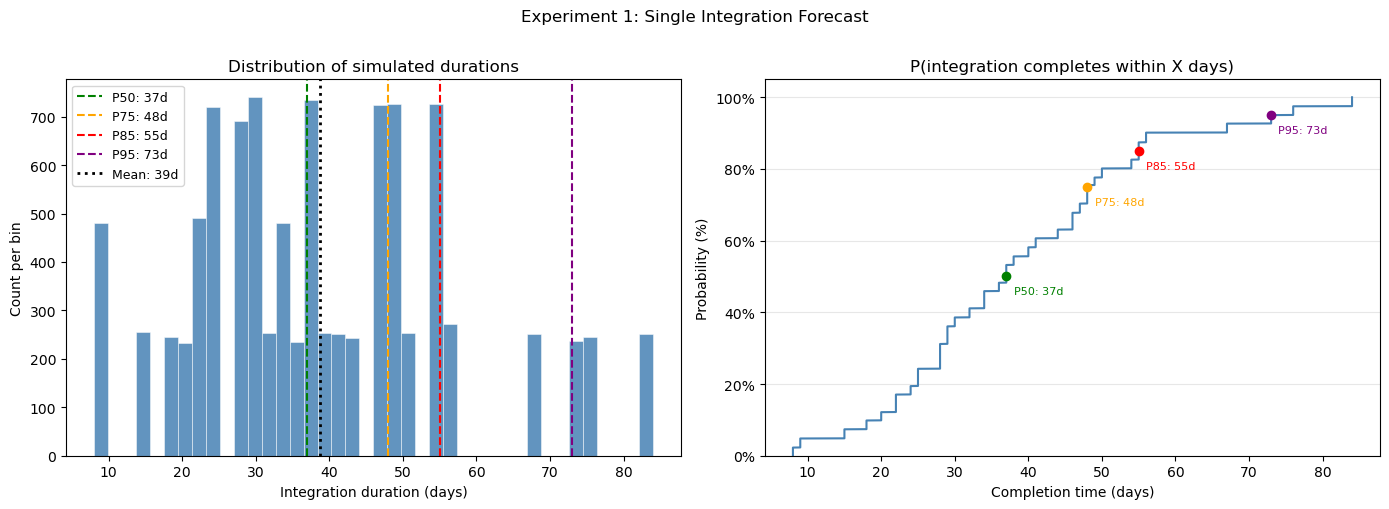


SAMPLE SIZE RELIABILITY for n = 41
P50  (needs n≥20  ): reliable
P75  (needs n≥40  ): reliable
P85  (needs n≥67  ): treat as directional
P95  (needs n≥200 ): low confidence


In [41]:
#Run Experiment 1 with following input:
result_1 = simulate_single_integration(
    historical_data=raw_jira_data,
    min_days=4,
    max_days=90,
    n_simulations=10_000,
    percentiles=[50, 75, 85, 95],
    random_seed=42,
)

review_experiment(result_1)

## Experiment 2: Multiple Integrations

In [25]:
def simulate_parallel_integrations(
    historical_data: list,
    integration_complexities: list,
    complexity_multipliers: dict,
    min_days: int = 4,
    max_days: int = 90,
    n_simulations: int = 10_000,
    percentiles: list = [50, 75, 85, 95],
    random_seed: int = 42,
) -> SimulationResult:
   #Validate inputs - complexities and complexity multipliers are mandatory inputs
    if len(integration_complexities) == 0:
        raise ValueError("integration_complexities must contain at least one entry.")

    for i, label in enumerate(integration_complexities):
        if label not in complexity_multipliers:
            raise ValueError(
                f"integration_complexities[{i}] = '{label}' is not defined in complexity_multipliers."
                f"Please pick one of the vailable labels: {list(complexity_multipliers.keys())}"
            )

    rng = np.random.default_rng(random_seed)
    n_integrations = len(integration_complexities)

    #Clean the data
    cleaned = clean_data(historical_data, min_days, max_days)
    removed = sorted([x for x in historical_data if x <= min_days or x > max_days])

    print(f"Raw observations: {len(historical_data)}")
    print(f"After cleaning: {len(cleaned)}")
    print(f"Removed: {len(removed)} values")
    print(f"Removed values: {removed}")
    print(f"\nIntegrations in parallel: {n_integrations}")

    #Run simulation build a [n_simulations, n_integrations] array.
    #Each column is one integration, each row is one simulation run.
    all_individual = np.zeros((n_simulations, n_integrations))

    for i, label in enumerate(integration_complexities):
        multiplier = complexity_multipliers[label]

        #Draw base cycle times from the empirical distribution
        base_draws = rng.choice(cleaned, size=n_simulations, replace=True)

        #Apply fixed complexity multiplier
        scaled = base_draws * multiplier
        all_individual[:, i] = scaled

    #Combined completion time = max across all integrations per run
    all_durations = np.max(all_individual, axis=1)

    #Compute results
    percentile_forecasts = compute_percentiles(all_durations, percentiles)

    result = SimulationResult(
        experiment_label=(
            f'Experiment 2: {n_integrations} Parallel Integrations '
            f'({", ".join(integration_complexities)})'
        ),
        cleaned_data=cleaned,
        all_durations=all_durations,
        percentile_forecasts=percentile_forecasts,
        mean=float(np.mean(all_durations)),
        median=float(np.median(all_durations)),
        std=float(np.std(all_durations)),
        parameters_used={
            'n_integrations': n_integrations,
            'integration_complexities': integration_complexities,
            'complexity_multipliers': complexity_multipliers,
            'min_days': min_days,
            'max_days': max_days,
            'n_simulations': n_simulations,
            'percentiles': percentiles,
            'random_seed': random_seed,
        }
    )

    #Store results in dataclass
    result._individual_durations = all_individual
    return result

### Review results of multiple integrations simulation

Raw observations: 43
After cleaning: 41
Removed: 2 values
Removed values: [0, 94]

Integrations in parallel: 3

EXPERIMENT 2: 3 PARALLEL INTEGRATIONS (SIMPLE, MEDIUM, MEDIUM) SUMMARY:

DATASET SUMMARY:
 Observations used: 41
 Min observed: 8 days
 Max observed: 84 days

SIMULATION STATISTICS SUMMARY:
 Mean: 50.3 days
 Median: 48.0 days
 Std deviation: 15.0 days
 Coeff of variation: 29.8%

PROBABILISTIC FORECAST:
 P50 : 48.0 days -> 50% chance all 3 integrations complete within 48 days
 P75 : 56.0 days -> 75% chance all 3 integrations complete within 56 days
 P85 : 67.0 days -> 85% chance all 3 integrations complete within 67 days
 P95 : 76.0 days -> 95% chance all 3 integrations complete within 76 days

POINT ESTIMATE vs MONTE CARLO
 Mean estimate: 38.7 days
 P85 (Monte Carlo): 67.0 days committing to the mean leaves a gap of 28 days

PER-INTEGRATION BREAKDOWN:
 Integration 1 (simple): mean=29.5d median=28.1d P85=41.8d
 Integration 2 (medium): mean=38.9d median=37.0d P85=55.0d
 Integra

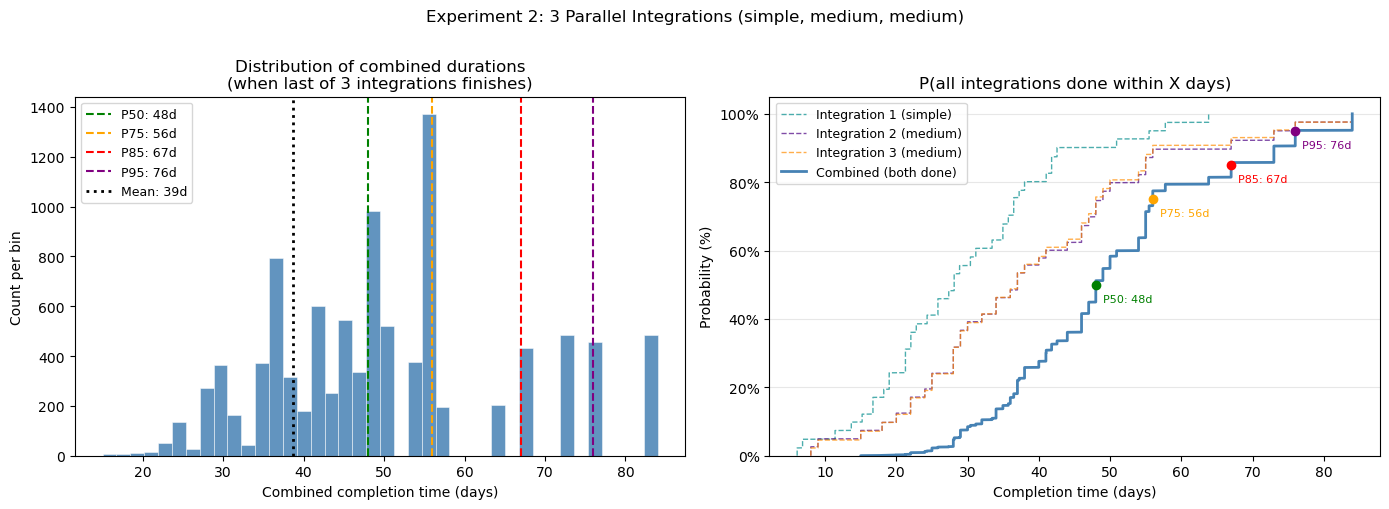


SAMPLE SIZE RELIABILITY for n = 41
P50  (needs n≥20  ): reliable
P75  (needs n≥40  ): reliable
P85  (needs n≥67  ): treat as directional
P95  (needs n≥200 ): low confidence


In [42]:
#Compute data-driven multipliers
_cleaned = clean_data(raw_jira_data, min_days=4, max_days=90)
_median  = np.median(_cleaned)

complexity_multipliers = {
    'simple': round(np.percentile(_cleaned, 30) / _median, 2),
    'medium': round(np.percentile(_cleaned, 50) / _median, 2),
    'complex': round(np.percentile(_cleaned, 75) / _median, 2),
}

#Run Experiment 2 with following input:
result_2 = simulate_parallel_integrations(
    historical_data = raw_jira_data,
    integration_complexities = ['simple', 'medium', 'medium'],
    complexity_multipliers = complexity_multipliers, #Could be manually passed as other constants as a dict {'name': value}
    min_days = 4,
    max_days = 90,
    n_simulations = 10_000,
    percentiles = [50, 75, 85, 95],
    random_seed = 42,
)

review_experiment(result_2)

## Analyse Limitations

## Conclution

## Resources
[1]. David P. Landau, Kurt Binder - A Guide to Monte Carlo Simulations in Statistical Physics (2014, Cambridge University Press) - https://www.eng.uc.edu/~beaucag/Classes/AdvancedMaterialsThermodynamics/Books/David%20P.%20Landau,%20Kurt%20Binder%20-%20A%20Guide%20to%20Monte%20Carlo%20Simulations%20in%20Statistical%20Physics%20(2014,%20Cambridge%20University%20Press)%20-%20libgen.lc.pdf

[2]. Quantifying Central Limit Theorem Convergence: A Monte Carlo Simulation Approach to Minimum Sample Size - https://ideas.repec.org/a/bcp/journl/v9y2025issue-8p639-644.html#:~:text=The%20findings%20support%20that%20a,statistical%20tests%20that%20need%20normality.

[3]. The story behind ‘random.seed(42)’ in machine learning - https://medium.com/geekculture/the-story-behind-random-seed-42-in-machine-learning-b838c4ac290a

[4]. List of named colors in matplot lib - https://matplotlib.org/stable/gallery/color/named_colors.html